# Nucleosome Repeat Length (NRL) and Effective Protection Size Simulations
This notebook estimates nucleosome repeat length (NRL) and effective nucleosome protection size in plasma cell-free DNA. We simulate cfDNA fragmentation from chromatin with active vs. inactive nucleosome configurations, then use Bayesian optimization to identify the NRL and protection size parameters that best reproduce observed correlations between fragment size and gene expression.

In [11]:
import os
# Limit threading for BLAS/OpenMP libs
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import math
import time
import json
import hashlib
from itertools import chain
from dataclasses import dataclass
from typing import Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm
from scipy.stats import pearsonr
from skopt import gp_minimize
from skopt.space import Integer

In [12]:
# load and process promoter correlation
sites_to_test = 'promoters'  # 'promoters' or 'enhancers'
expr_corr_path = 'promoter_smoothed.csv' if sites_to_test == 'promoters' else 'enhancer_smoothed.csv'

TSS_bounds = (3000, 5000)  # limit to shoulder regions

df_wide = pd.read_csv(expr_corr_path)
distance_cols = [c for c in df_wide.columns if c != "size_bin"]

df_long = df_wide.melt(
    id_vars="size_bin",
    value_vars=distance_cols,
    var_name="distance_bin",
    value_name="frequency_correlation"
)

df_long["distance_bin"] = pd.to_numeric(df_long["distance_bin"], errors="coerce")
df_long["frequency_correlation"] = pd.to_numeric(df_long["frequency_correlation"], errors="coerce")
df_long = df_long[np.isfinite(df_long["distance_bin"]) & np.isfinite(df_long["frequency_correlation"])]

mask = (
    (df_long["distance_bin"].abs() >  TSS_bounds[0]) &
    (df_long["distance_bin"].abs() <  TSS_bounds[1])
)
expr_corr = df_long[mask].copy()

# Group by size_bin and average
target_corr = (
    expr_corr
    .groupby("size_bin", as_index=False)["frequency_correlation"]
    .mean()
    .rename(columns={"frequency_correlation": "corr"})
)

target_corr = target_corr.sort_values("size_bin").reset_index(drop=True)

In [13]:
# simulator
std_size_inactive = 10
std_size_active = 10
on_nuc_cut_rate = 0.001
cut_attempts_mean = 10000
cut_attempts_sd = 1000
interval_bp = 100000

# Models cfDNA generation through nuclease digestion of chromatin
def simcuts(max_nucs, NRL, spacing_sd, mean_size_eff, std_size_eff, 
            tot_bp, cuts_mean, cuts_sd, on_cut_rate, rng):
    """Simulate cfDNA fragment lengths from nuclease digestion."""
    
    # Place nucleosomes
    spacing = rng.normal(NRL, spacing_sd, max_nucs).round()
    centers = np.cumsum(spacing)
    size_eff = np.maximum(1, rng.normal(mean_size_eff, std_size_eff, len(centers)).round())
    starts, ends = centers - size_eff // 2, centers + size_eff // 2
    nucs = np.vstack([starts, ends]).T[(starts >= 1) & (ends < tot_bp)]
    
    # Generate cuts
    n_cuts = max(1, int(rng.normal(cuts_mean, cuts_sd)))
    cuts = rng.uniform(1, tot_bp, n_cuts)
    
    # Identify cuts overlapping nucleosomes
    cut_in_nuc = (np.any((cuts[:, None] >= nucs[:, 0]) & (cuts[:, None] <= nucs[:, 1]), axis=1) 
                  if nucs.size > 0 else np.zeros(len(cuts), dtype=bool))
    
    # Keep fraction of overlapping cuts
    n_on = int(cut_in_nuc.sum() * on_cut_rate)
    on_nuc_cuts = rng.choice(cuts[cut_in_nuc], n_on, replace=False) if n_on > 0 else np.array([])
    
    # Combine and sort all retained cuts
    cuts_made = np.sort(np.concatenate([cuts[~cut_in_nuc], on_nuc_cuts]))
    
    # Return fragment lengths
    return np.diff(np.concatenate([[0], cuts_made, [tot_bp]]))


def simulate_once(NRL_active, NRL_inactive, size_active, size_inactive, rng):
    """Generate one active and one inactive fragment-length draw using simcuts."""
    spacing_sd_inactive = np.abs(rng.normal(10, 2))
    spacing_sd_active   = np.abs(rng.normal(10, 2))
    NRL_inactive_val    = rng.normal(NRL_inactive, 5)
    NRL_active_val      = rng.normal(NRL_active, 5)

    max_nucs = int(np.ceil(interval_bp / max(NRL_inactive, NRL_active) + 5000))
    
    # Simulate active chromatin fragmentation
    active_frags = simcuts(
        max_nucs=max_nucs,
        NRL=NRL_active_val,
        spacing_sd=spacing_sd_active,
        mean_size_eff=size_active,
        std_size_eff=std_size_active,
        tot_bp=interval_bp,
        cuts_mean=cut_attempts_mean,
        cuts_sd=cut_attempts_sd,
        on_cut_rate=on_nuc_cut_rate,
        rng=rng
    )
    
    # inactive fragmentation
    inactive_frags = simcuts(
        max_nucs=max_nucs,
        NRL=NRL_inactive_val,
        spacing_sd=spacing_sd_inactive,
        mean_size_eff=size_inactive,
        std_size_eff=std_size_inactive,
        tot_bp=interval_bp,
        cuts_mean=cut_attempts_mean,
        cuts_sd=cut_attempts_sd,
        on_cut_rate=on_nuc_cut_rate,
        rng=rng
    )
    return active_frags, inactive_frags

In [ ]:
# Configs
PENALTY       = 10.0
RUN_SALT      = 14 
K             = 3
N_SIM         = 300
N_JOBS        = 12
EPS           = 1e-6
BIN_EDGES = np.arange(50, 505, 5)
BIN_MIDS = ((BIN_EDGES[1:] + BIN_EDGES[:-1]) / 2).astype(int)

# Prepare target
if "size_bin" not in target_corr.columns:
    target_corr = target_corr.rename(columns={"fragment_size": "size_bin"})

t_aligned = target_corr.set_index("size_bin")["corr"].reindex(BIN_MIDS)
sel_mask = ~t_aligned.isna().to_numpy()
target_vec = t_aligned.dropna().to_numpy()

def get_frag_length_distribution(frag_lengths):
    """Return density on global bins, aligned by fragment_size."""
    frag = frag_lengths[(frag_lengths > 90) & (frag_lengths < 500)]
    density, _ = np.histogram(frag, bins=BIN_EDGES, density=True)
    return pd.DataFrame({'fragment_size': BIN_MIDS, 'density': density})

def seed_from_params(x, salt):
    b = json.dumps(tuple(map(int, x)), separators=(',', ':')).encode()
    s = int(salt).to_bytes(4, 'big')
    d = hashlib.blake2b(b + b'|' + s, digest_size=4).digest()
    return int.from_bytes(d, 'big')

def spawn_seeds(x, K=K, N=N_SIM, salt=RUN_SALT):
    kids = np.random.SeedSequence(seed_from_params(tuple(x), salt)).spawn(K * N)
    return [kids[i].generate_state(1, dtype=np.uint32)[0] for i in range(K * N)]

def _one_sim_counts(seed, pars):
    """Simulate one replicate and return per-bin fragment counts."""
    rng = np.random.default_rng(seed)
    a, b = simulate_once(*pars, rng)
    cntA, _ = np.histogram(a[(a > BIN_EDGES[0]) & (a < BIN_EDGES[-1])], bins=BIN_EDGES)
    cntB, _ = np.histogram(b[(b > BIN_EDGES[0]) & (b < BIN_EDGES[-1])], bins=BIN_EDGES)
    return cntA.astype(np.int64), cntB.astype(np.int64)

def corr_for_batch(sumA, sumB):
    """Fits simulated fragment patterns to experimental cfDNA-expression correlations."""
    A, B = sumA[sel_mask].astype(float), sumB[sel_mask].astype(float)
    if A.size < 2: return np.nan
    ratio = np.log2((B + EPS) / (A + EPS))
    if not np.all(np.isfinite(ratio)): return np.nan
    r = pearsonr(ratio, target_vec)[0]
    return r if np.isfinite(r) else np.nan

def eval_K_batches(pars, seeds, K=K, N=N_SIM, n_jobs=N_JOBS):
    """Evaluate correlation in K batches of N replicates under params."""
    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(_one_sim_counts)(seed, pars) for seed in seeds
    )
    
    cors = []
    for k in range(K):
        sumA, sumB = map(lambda x: sum(x).astype(np.int64), 
                         zip(*results[k*N:(k+1)*N]))
        r = corr_for_batch(sumA, sumB)
        if not np.isfinite(r): return np.nan, np.nan
        cors.append(r)
    
    cors = np.array(cors)
    return float(cors.mean()), float(cors.std(ddof=0))

def feasible(x):
    """Hard constraints: inactive ≥ active; each NRL ≥ size+10."""
    Na, Ni, Sa, Si = x
    return Ni >= Na and Ni >= Si + 10 and Na >= Sa + 10

In [ ]:
from skopt.space import Integer
import numpy as np

def map_to_feasible(x):
    # x = [NRL_active0, NRL_inactive0, size_active0, size_inactive0]
    Na0, Ni0, Sa0, Si0 = map(int, x)

    # Enforce NRL >= size + 10
    Na1 = max(Na0, Sa0 + 10)
    Ni1 = max(Ni0, Si0 + 10)

    # Enforce ordering: inactive >= active
    Ni2 = max(Ni1, Na1)

    Na = int(np.clip(Na1, 140, 215))
    Ni = int(np.clip(Ni2, 140, 215))
    Sa = int(np.clip(Sa0, 120, 190))
    Si = int(np.clip(Si0, 120, 190))
    return [Na, Ni, Sa, Si]

space = [
    Integer(140, 215, name='NRL_active'),
    Integer(140, 215, name='NRL_inactive'),
    Integer(120, 190, name='size_active'),
    Integer(120, 190, name='size_inactive'),
]

def sample_uniform(n, salt=42):
    rng = np.random.default_rng(salt)
    lows  = [140, 140, 120, 120]
    highs = [215, 215, 190, 190]
    return [[int(rng.integers(l, h+1)) for l, h in zip(lows, highs)] for _ in range(n)]

def objective_with_pool(x, seed_pool):
    sim_x = map_to_feasible(x)
    r_mean, r_std = eval_K_batches(sim_x, seed_pool, K=K, N=N_SIM, n_jobs=N_JOBS)
    if not np.isfinite(r_mean):
        return 10.0
    return float(1.0 + r_mean)

def make_seed_pool(salt, K, N):
    ss = np.random.SeedSequence(int(salt))
    kids = ss.spawn(K * N)
    return [kids[i].generate_state(1, dtype=np.uint32)[0] for i in range(K * N)]


best_params = []
S = 5
for run in range(S):
#     f_run =
    seed_pool = make_seed_pool(1000 + run, K, N_SIM)

    # Close over this pool so it's constant within the run
    f_run = lambda x: objective_with_pool(x, seed_pool)
    
    x0 = sample_uniform(20, salt=run)
    res = gp_minimize(
        func=f_run,
        dimensions=space,
        acq_func='EI',
        xi=0.02,
        n_calls=200,
        n_random_starts=0,
        x0=x0,
        noise="gaussian",
        n_restarts_optimizer=2,
        random_state=run,
        verbose=True
    )
    best_params.append(res.x)


In [35]:
def adaptive_ranges(best_params, max_combos=1000):
    """Generate parameter ranges targeting max_combos total combinations."""
    best_params = np.array(best_params)
    means = np.mean(best_params, axis=0)
    spans = np.ptp(best_params, axis=0)
    
    target_per_dim = int(max_combos ** 0.25)  # 4th root, ~5.3 for 800
    ranges = {}
    
    for i, name in enumerate(["active_nrl", "inactive_nrl", "active_size", "inactive_size"]):
        exp = max(6, spans[i] * 2) if spans[i] > 0 else 6
        start, end = int(means[i] - exp/2), int(means[i] + exp/2)
        
        # Create full range then sample target_per_dim points
        full_range = list(range(start, end + 1))
        if len(full_range) <= target_per_dim:
            ranges[name] = full_range
        else:
            # Sample evenly spaced points
            indices = np.linspace(0, len(full_range)-1, target_per_dim, dtype=int)
            ranges[name] = [full_range[i] for i in indices]
    
    return ranges

ranges=adaptive_ranges(best_params)
ranges

{'active_nrl': [134, 140, 146, 152, 158],
 'inactive_nrl': [197, 199, 202, 204, 207],
 'active_size': [128, 131, 134, 137, 140],
 'inactive_size': [177, 178, 180, 181, 183]}

In [36]:
import itertools as it
import numpy as np
import pandas as pd

K = 3           
N_SIM = 1000      
N_JOBS =  64
RUN_SALT = 12345  

def to_param_list(d):
    return [d["active_nrl"], d["inactive_nrl"], d["active_size"], d["inactive_size"]]

def grid_points(ranges):
    keys = list(ranges.keys())
    for vals in it.product(*[ranges[k] for k in keys]):
        d = dict(zip(keys, vals))
        yield d
        
rows = []
total_points = len(list(grid_points(ranges)))

pbar = tqdm(grid_points(ranges), total=total_points)

for d in pbar:
    pbar.set_description(f"NRL:{d['active_nrl']},{d['inactive_nrl']} Size:{d['active_size']},{d['inactive_size']}")
    
    x = to_param_list(d)
    if 'feasible' in globals() and not feasible(x):
        continue

    seeds = spawn_seeds(x, K=K, N=N_SIM, salt=RUN_SALT)
    
    r_mean, r_std = eval_K_batches(x, seeds=seeds, K=K, N=N_SIM, n_jobs=N_JOBS)
    loss = 1.0 + r_mean

    rows.append({
        "active_nrl": d["active_nrl"],
        "inactive_nrl": d["inactive_nrl"],
        "active_size": d["active_size"],
        "inactive_size": d["inactive_size"],
        "r_mean": float(r_mean),
        "r_sd": float(r_std),
        "loss": float(loss)
    })

df = pd.DataFrame(rows)
df = df.sort_values(["loss","r_sd"]).reset_index(drop=True)

# Inspect top candidates
print(df.head(10))
best = df.iloc[0][["active_nrl","inactive_nrl","active_size","inactive_size"]].to_dict()
print("Best:", best)

NRL:158,207 Size:140,183: 100%|██████████| 625/625 [30:55<00:00,  2.97s/it]

   active_nrl  inactive_nrl  active_size  inactive_size    r_mean      r_sd  \
0         146           207          134            177 -0.900974  0.001085   
1         146           207          134            178 -0.899345  0.002535   
2         146           204          134            177 -0.899039  0.003101   
3         146           207          131            178 -0.898063  0.001680   
4         146           204          134            178 -0.895562  0.000880   
5         146           207          134            180 -0.894972  0.001110   
6         152           207          131            177 -0.894858  0.001314   
7         146           202          134            177 -0.893483  0.001132   
8         146           204          134            180 -0.893356  0.000678   
9         152           207          128            177 -0.893125  0.000595   

       loss  
0  0.099026  
1  0.100655  
2  0.100961  
3  0.101937  
4  0.104438  
5  0.105028  
6  0.105142  
7  0.106517  
8  0

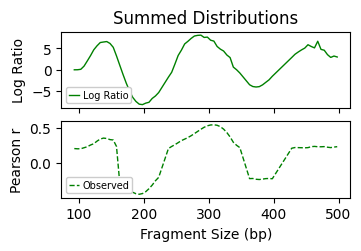

r = 0.9015


In [57]:
# Visualize best params
NRL_active, NRL_inactive, size_active, size_inactive = best.values()
ss = np.random.SeedSequence(seed_from_params(tuple(best.values()), 1000))
N_SIMULATIONS, N_JOBS = 1000, 64

# Prepare target
target = target_corr.copy()
target[["size_bin", "corr"]] = target[["size_bin", "corr"]].apply(pd.to_numeric, errors="coerce")
target = target[(target["size_bin"] > 50) & np.isfinite(target["corr"])]

def run_one_counts(seed_seq):
    """One replicate → counts for (active, inactive)."""
    seed = seed_seq.generate_state(1, dtype=np.uint32)[0]
    rng = np.random.default_rng(seed)
    fragA, fragB = simulate_once(NRL_active, NRL_inactive, size_active, size_inactive, rng)
    cntA, _ = np.histogram(fragA[(fragA > 90) & (fragA < 500)], bins=BIN_EDGES)
    cntB, _ = np.histogram(fragB[(fragB > 90) & (fragB < 500)], bins=BIN_EDGES)
    return cntA.astype(np.int64), cntB.astype(np.int64)

# Run simulations and sum
results = Parallel(n_jobs=N_JOBS, backend="loky")(
    delayed(run_one_counts)(kid) for kid in ss.spawn(N_SIMULATIONS)
)
sumA, sumB = map(lambda x: sum(x).astype(np.int64), zip(*results))

# Compute log ratio and align
log_ratio = np.log2((sumA + 1e-12) / (sumB + 1e-12))
aligned = target.merge(pd.DataFrame({"size_bin": BIN_MIDS, "log_ratio": log_ratio}), 
                       on="size_bin", how="left").fillna(0)
m = np.isfinite(aligned["log_ratio"]) & np.isfinite(aligned["corr"])
r, _ = pearsonr(aligned.loc[m, "log_ratio"], aligned.loc[m, "corr"])

# Plot
fig, axes = plt.subplots(2, 1, figsize=(3.5, 2.4), sharex=True, 
                         constrained_layout=True)  # Remove hspace, use constrained_layout

legend_kw = dict(loc="lower left", fontsize=7, frameon=True, framealpha=1, 
                 handlelength=1, handletextpad=0.4, borderpad=0.3, labelspacing=0.3)

axes[0].plot(aligned["size_bin"], aligned["log_ratio"], label="Log Ratio", linewidth=1, color="green")
axes[0].set_ylabel("Log Ratio")
axes[0].set_title(f"Summed Distributions")
axes[0].legend(**legend_kw)

axes[1].plot(target["size_bin"], target["corr"], label="Observed", linewidth=1, linestyle="--", color="green")
axes[1].set_xlabel("Fragment Size (bp)")
axes[1].set_ylabel("Pearson r")
axes[1].legend(**legend_kw)

plt.show()
print(f"r = {r:.4f}")

[size] Best: mu_a=150, mu_i=164, std=5; peak=135.0/134.0, trough=180.0/177.0, diff=4.00


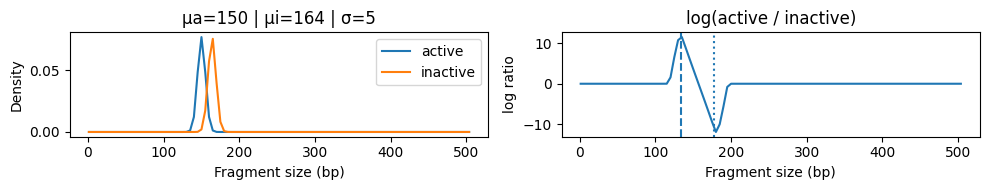

[nrl] Best: mu_a=166, mu_i=184, std=6; peak=145.0/146.0, trough=205.0/207.0, diff=3.00


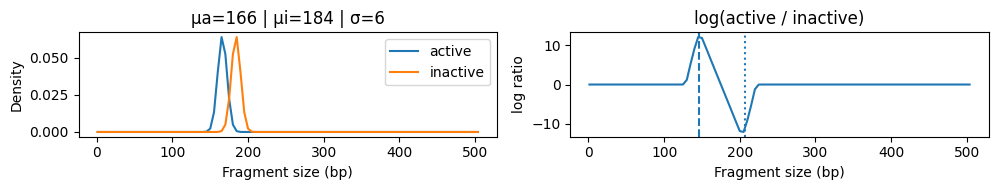

In [54]:
# Targets 
ACTIVE_NRL_TARGET, INACTIVE_NRL_TARGET, ACTIVE_SIZE_TARGET, INACTIVE_SIZE_TARGET = best.values()

MEAN_RANGE = np.arange(130, 221, 2)
STD_RANGE = np.arange(5, 10, 1) 
BINS_LO, BINS_HI, BIN_W = 0, 505, 5
N_JOBS = -1
SAVE = False
OUTDIR = "fit_outputs"
USE_WINDOWS = True
WINDOW_BP = 15

@dataclass(frozen=True)
class Targets:
    label: str
    active_max: float
    inactive_max: float

def normal_bin_density(bins, mu, sigma, lo=0.0, hi=500.0):
    b0, b1 = np.maximum(bins[:-1], lo), np.minimum(bins[1:], hi)
    w = np.clip(b1 - b0, 0.0, None)
    mids = 0.5 * (b0 + b1)
    
    erf = np.vectorize(math.erf, otypes=[float])
    z_hi, z_lo = (b1 - mu) / (sigma * np.sqrt(2)), (b0 - mu) / (sigma * np.sqrt(2))
    mass = 0.5 * (erf(z_hi) - erf(z_lo))
    
    z_hi_all, z_lo_all = (hi - mu) / (sigma * np.sqrt(2)), (lo - mu) / (sigma * np.sqrt(2))
    mass_total = max(0.5 * (erf(z_hi_all) - erf(z_lo_all)), 1e-15)
    
    dens = np.zeros_like(mids)
    ok = w > 0
    dens[ok] = (mass[ok] / mass_total) / w[ok]
    return mids, dens

def compute_fit(mu_a, mu_i, sig, active_max, inactive_max, eps=1e-9):
    if not (mu_a < mu_i) or abs(mu_i - mu_a) > 3.0 * sig:
        return None
    
    bins = np.arange(BINS_LO - BIN_W/2, BINS_HI + BIN_W/2 + 1e-9, BIN_W)
    mids, a = normal_bin_density(bins, mu_a, sig, BINS_LO, BINS_HI)
    _, i = normal_bin_density(bins, mu_i, sig, BINS_LO, BINS_HI)
    
    log_ratio = np.log((a + eps) / (i + eps))
    peak_idx, trough_idx = int(np.argmax(log_ratio)), int(np.argmin(log_ratio))
    peak_bp, trough_bp = mids[peak_idx], mids[trough_idx]
    
    return dict(
        mean_active=mu_a, mean_inactive=mu_i, std=sig,
        mids=mids, a_dens=a, i_dens=i, log_ratio=log_ratio,
        peak_bp=peak_bp, trough_bp=trough_bp,
        peak_idx=peak_idx, trough_idx=trough_idx,
        diff_combined=float(abs(peak_bp - active_max) + abs(trough_bp - inactive_max))
    )

def grid_search(targets: Targets):
    grid = [(ma, mi, sd) for ma in MEAN_RANGE for mi in MEAN_RANGE for sd in STD_RANGE]
    results = Parallel(n_jobs=N_JOBS, verbose=0)(
        delayed(compute_fit)(ma, mi, sd, targets.active_max, targets.inactive_max)
        for ma, mi, sd in grid
    )
    valid = [r for r in results if r]
    if not valid:
        raise RuntimeError("No valid results")
    return min(valid, key=lambda r: r["diff_combined"])

def plot_all(best: Dict[str, Any], targets: Targets):
    out = os.path.join(OUTDIR, targets.label) if SAVE else ""
    if SAVE:
        os.makedirs(OUTDIR, exist_ok=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 2))
    
    # Densities
    axes[0].plot(best["mids"], best["a_dens"], label="active")
    axes[0].plot(best["mids"], best["i_dens"], label="inactive")
    axes[0].set_title(f"μa={best['mean_active']} | μi={best['mean_inactive']} | σ={best['std']}")
    axes[0].set_xlabel("Fragment size (bp)")
    axes[0].set_ylabel("Density")
    axes[0].legend()

    
    # Log ratio
    axes[1].plot(best["mids"], best["log_ratio"])
    axes[1].axvline(x=targets.active_max, linestyle='--')
    axes[1].axvline(x=targets.inactive_max, linestyle=':')
    axes[1].set_title("log(active / inactive)")
    axes[1].set_xlabel("Fragment size (bp)")
    axes[1].set_ylabel("log ratio")
    
    plt.tight_layout()
    if SAVE:
        plt.savefig(f"{out}_all.png", dpi=300)
        plt.savefig(f"{out}_all.pdf")
    plt.show()

def run_fit(targets: Targets):
    best = grid_search(targets)
    print(f"[{targets.label}] Best: mu_a={best['mean_active']}, mu_i={best['mean_inactive']}, "
          f"std={best['std']}; peak={best['peak_bp']:.1f}/{targets.active_max}, "
          f"trough={best['trough_bp']:.1f}/{targets.inactive_max}, diff={best['diff_combined']:.2f}")
    plot_all(best, targets)

# Run
run_fit(Targets("size", ACTIVE_SIZE_TARGET, INACTIVE_SIZE_TARGET))
run_fit(Targets("nrl", ACTIVE_NRL_TARGET, INACTIVE_NRL_TARGET))